In [1]:
import os
import json
import pandas as pd
#cluster/home/svangelova/computational taxonomy/Checkpoint 2/final notebooks/251030_generated_descriptions_Apertus-8B-Instruct-2509s
directory_path = "./251030_generated_descriptions_Apertus-8B-Instruct-2509s"
data_list = []
# Iterate through all files in the directory
for filename in os.listdir(directory_path):
    if filename.endswith('.json'):
        file_path = os.path.join(directory_path, filename)
        with open(file_path, 'r', encoding='utf-8') as file:
            try:
                data = json.load(file)
                # Ensure it's a dict with 4 key-value pairs
                if isinstance(data, dict):
                    if data["data_point"] == "":
                        print(f"Skipping {filename}, data point empty")
                    
                        continue
                    data_list.append(data)
                else:
                    print(f"Skipping {filename}")
            except json.JSONDecodeError:
                print(f"Skipping {filename}: invalid JSON format.")
                
# Convert list of dicts to DataFrame
df = pd.DataFrame(data_list)
df.tail()

,question,original_source,data_group,data_point,reference_1,reference_2,description,references
2005,What is the meaning of eco-toxicity in relatio...,CPR 2024.pdf,essential environmental characteristics,eco-toxicity,CPR 2024.pdf,BAMB 2019.pdf,Eco-toxicity refers to the harmful effects of...,[{'text': 'ANNEX II Predetermined environmenta...
2006,What is the meaning of freshwater in relation ...,CPR 2024.pdf,essential environmental characteristics,freshwater,CPR 2024.pdf,CPR 2024.pdf,(g) eutrophication aquatic freshwater; \nThis...,[{'text': 'ANNEX II Predetermined environmenta...
2007,What is the meaning of human toxicity cancerog...,CPR 2024.pdf,essential environmental characteristics,human toxicity cancerogenic,CPR 2024.pdf,BAMB 2019.pdf,"Human toxicity, cancerogenic refers to the po...",[{'text': 'ANNEX II Predetermined environmenta...
2008,What is the meaning of human toxicity non-canc...,CPR 2024.pdf,essential environmental characteristics,human toxicity non-cancerogenic,CPR 2024.pdf,BAMB 2019.pdf,Human toxicity non-cancerogenic refers to the...,[{'text': 'ANNEX II Predetermined environmenta...
2009,What is the meaning of land use related impact...,CPR 2024.pdf,essential environmental characteristics,land use related impacts,CPR 2024.pdf,Kebede 2024.pdf,Land use related impacts refer to the effects...,[{'text': 'ANNEX II Predetermined environmenta...


In [2]:
import pandas as pd

initial_groups_df = pd.read_excel('./data/251027 input data points and groups.xlsx')
initial_groups_df['Data_groups'] = initial_groups_df['Data_groups']\
    .str.strip().str.lower().str.replace('&', 'and')
initial_groups_df.head()

,Data_groups,Data_points,Source,File,Passport_type
0,general information,"Product commercial name, Manufacturer's name, ...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport
1,material health,"Security information, warnings, recommendation...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport
2,sustainability,"Environmental declaration, Life cycle assessme...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport
3,design and production,"Manufacturing process, Manufacturing technique...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport
4,use and operate phase,"Positioning in the building, location in the b...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport


In [3]:
passport_type_map = {}
for i in range(initial_groups_df.shape[0]):
    document = initial_groups_df.iloc[i].File
    passport = initial_groups_df.iloc[i].Passport_type

    passport_type_map[document] = passport

passport_type_map

{'Munaro and Tavares 2021.pdf': 'Material passport',
 'Giovanardi 2023.pdf': 'Digital passport',
 'Çetin 2023.pdf': 'Material passport',
 'Kebede 2024.pdf': 'Digital product passport',
 'Atta 2021.pdf': 'Material passport',
 'Göswein 2022.pdf': 'Material passport',
 'Heisel and Rau-Oberhuber 2020.pdf': 'Material passport',
 'Honic 2019.pdf': 'Material passport',
 'Honic 2021.pdf': 'Material passport',
 'Mulhall 2022.pdf': 'Product Circularity Data Sheet',
 'BAMB 2019.pdf': 'Material passport',
 'Platform CB 2023.pdf': 'Material passport',
 'Bauen digital Schweiz 2024.pdf': 'Digital product passport',
 'Bosma 2024.pdf': 'Digital product passport',
 'Mao and Cao 2025.pdf': 'Material passport',
 'Markou 2025.pdf': 'Material passport',
 'Wan and Jiang 2025.pdf': 'Digital product passport',
 'Byers 2025.pdf': 'Material passport',
 'ISO 59040 2025.pdf': 'Product Circularity Data Sheet',
 'Seddiqui 2024.pdf': 'Material passport',
 'Van Capelleveen 2023.pdf': 'Digital passport',
 'KC 2024.pdf'

In [4]:
from collections import Counter

Counter(initial_groups_df.groupby('File').apply(max).Passport_type)

/scratch/tmp.52491915.svangelova/ipykernel_589819/3207186640.py:3: FutureWarning: The provided callable <built-in function max> is currently using np.maximum.reduce. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.maximum.reduce instead.
  Counter(initial_groups_df.groupby('File').apply(max).Passport_type)
/scratch/tmp.52491915.svangelova/ipykernel_589819/3207186640.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Counter(initial_groups_df.groupby('File').apply(max).Passport_type)


Counter({'Material passport': 14,
         'Digital product passport': 12,
         'Digital passport': 2,
         'Product Circularity Data Sheet': 2})

In [5]:
initial_groups_df.groupby('File').apply(lambda x: x.shape[0])

/scratch/tmp.52491915.svangelova/ipykernel_589819/1459773636.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  initial_groups_df.groupby('File').apply(lambda x: x.shape[0])


File
Atta 2021.pdf                         4
BAMB 2019.pdf                        13
Bauen digital Schweiz 2024.pdf        9
Bosma 2024.pdf                       14
Byers 2025.pdf                        3
CPR 2024.pdf                          6
Christensen 2025.pdf                  3
Circularise 2025.pdf                  7
ESPR 2024.pdf                        15
Giovanardi 2023.pdf                  12
Göswein 2022.pdf                      3
Heisel and Rau-Oberhuber 2020.pdf     5
Honic 2019.pdf                        1
Honic 2021.pdf                        1
ISO 59040 2025.pdf                   26
Jensen 2023.pdf                       7
KC 2024.pdf                           6
Kebede 2024.pdf                       8
Lopes and Barata 2024.pdf             8
Mao and Cao 2025.pdf                 33
Markou 2025.pdf                      34
Mulhall 2022.pdf                      7
Munaro and Tavares 2021.pdf           9
Platform CB 2023.pdf                 10
Ruismäki 2025.pdf                  

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from sentence_transformers import SentenceTransformer


model = SentenceTransformer('./cluster/scratch/svangelova')

#### Clustering using descriptions

In [7]:
description_embeddings = model.encode(df["description"])

In [8]:
import joblib

study = joblib.load("02_251222_multi_clusterdata_descriptions_Apertus-8B-Instruct.pkl")


In [9]:
# Read CSV file
df_descriptions_phi = pd.read_csv('02_251222_multi_clusterdata_descriptions_Apertus-8B-Instruct.csv')

descriptions_trials_data = study.trials_dataframe()[((df_descriptions_phi['user_attrs_ccc_score'] > 0.575) & (df_descriptions_phi['user_attrs_dbcv_score'] > 0.5) &
                     (df_descriptions_phi['user_attrs_n_clusters'] > 2))].sort_values (['user_attrs_n_clusters','values_0'])

In [10]:
descriptions_trials_data

,number,values_0,values_1,datetime_start,datetime_complete,duration,params_cluster_selection_epsilon,params_min_cluster_size,params_min_dist,params_min_samples,params_n_components,params_n_neighbors,user_attrs_ccc_score,user_attrs_dbcv_score,user_attrs_n_clusters,user_attrs_outlier_ratio,system_attrs_NSGAIISampler:generation,state
249,249,0.774526,0.548327,2025-12-22 20:17:37.138273,2025-12-22 20:17:47.844624,0 days 00:00:10.706351,0.08,46,0.28,20,10,32,0.774526,0.548327,7,0.523881,4,COMPLETE
239,239,0.616636,0.550584,2025-12-22 20:15:53.693269,2025-12-22 20:16:04.543301,0 days 00:00:10.850032,0.05,44,0.07,20,12,26,0.616636,0.550584,11,0.431841,4,COMPLETE
205,205,0.616732,0.514278,2025-12-22 20:09:59.248239,2025-12-22 20:10:09.923179,0 days 00:00:10.674940,0.02,42,0.10,20,12,21,0.616732,0.514278,12,0.386070,4,COMPLETE
295,295,0.676236,0.525721,2025-12-22 20:25:27.739168,2025-12-22 20:25:38.200963,0 days 00:00:10.461795,0.01,44,0.07,20,7,26,0.676236,0.525721,12,0.422388,5,COMPLETE
299,299,0.642301,0.504278,2025-12-22 20:26:11.146042,2025-12-22 20:26:19.450178,0 days 00:00:08.304136,0.24,34,0.15,17,5,3,0.642301,0.504278,13,0.276119,5,COMPLETE
281,281,0.691615,0.518953,2025-12-22 20:23:00.220313,2025-12-22 20:23:11.044717,0 days 00:00:10.824404,0.01,36,0.07,20,10,32,0.691615,0.518953,13,0.372139,5,COMPLETE
153,153,0.658607,0.505925,2025-12-22 20:00:41.721423,2025-12-22 20:00:52.168463,0 days 00:00:10.447040,0.23,34,0.00,17,10,22,0.658607,0.505925,14,0.287065,3,COMPLETE
123,123,0.576353,0.556582,2025-12-22 19:55:25.870888,2025-12-22 19:55:34.585668,0 days 00:00:08.714780,0.05,29,0.14,19,14,3,0.576353,0.556582,17,0.229851,2,COMPLETE
277,277,0.585866,0.542002,2025-12-22 20:22:19.939890,2025-12-22 20:22:28.664492,0 days 00:00:08.724602,0.05,29,0.14,18,14,3,0.585866,0.542002,17,0.223383,5,COMPLETE
168,168,0.591473,0.533452,2025-12-22 20:03:22.804091,2025-12-22 20:03:33.744111,0 days 00:00:10.940020,0.07,7,0.15,19,6,40,0.591473,0.533452,23,0.436816,3,COMPLETE


In [11]:
def get_trial_description(trials, trial_number):
    trial = trials.iloc[trial_number]

    fig_title = (
        f"Apertus-8B-Instruct, Trial {trial['number']}<br>"
        f"Params: n_neighbors={trial['params_n_neighbors']}, n_components={trial['params_n_components']}, "
        f"min_cluster_size={trial['params_min_cluster_size']}, min_samples={trial['params_min_samples']}<br>"
        f"Metrics: DBCV={trial['user_attrs_dbcv_score']:.3f}, CCC={trial['user_attrs_ccc_score']:.3f}, "
        f"Outlier Ratio={trial['user_attrs_outlier_ratio']:.3f}, Clusters={trial['user_attrs_n_clusters']}"
    )

    return fig_title

get_trial_description(descriptions_trials_data, 0)

'Apertus-8B-Instruct, Trial 249<br>Params: n_neighbors=32, n_components=10, min_cluster_size=46, min_samples=20<br>Metrics: DBCV=0.548, CCC=0.775, Outlier Ratio=0.524, Clusters=7'

In [12]:
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def extract_topic_lists(group):
    """Return grouped lists for data_group, data_point, and description."""
    topic_dict = {}
    topic_dict["topic"] = group.iloc[0]["description_topic"]
    topic_name_original = group.iloc[0]["description_topic_name"]
    
    data_point_names = []
    data_point_descriptions = []

    for i in range(group.shape[0]):
        data_point_names.append(group.iloc[i]["data_point"])
        data_point_descriptions.append(group.iloc[i]["description"])
    

    # Get embeddings for each term
    term_embeddings = model.encode(data_point_names)
    
    # dot = cosine_similarity(term_embeddings, description_topic_model.topic_embeddings_[topic_dict["topic"]].reshape(-1, 1).T)
    
    # best_idx = dot.argmax()
    # best_term = data_point_names[best_idx]
    
    # # Compute the centroid
    centroid = np.mean(term_embeddings, axis=0).reshape(1, -1)

    # original_topic_name = ' '.join([v for v in description_topic_model.get_topic_info(topic_dict["topic"]).Representation[:4]][0])
    #' '.join([word for word in description_topic_model.get_topic_info(topic_dict["topic"]).Name[0].split("_")[1:]])
    # centroid = model.encode(original_topic_name).reshape(-1, 1).T
    
    sims = cosine_similarity(centroid, term_embeddings)[0]
    sorted_ids = np.argsort(sims)[::-1]
    best_idx = sorted_ids[0]#np.argmax(sims)
    best_term = data_point_names[best_idx]
    

    topic_dict["data_points"] = []
    topic_dict["references"] = []
    topic_dict["passports"] = []

    data_point_names_sorted = []
    
    for i in sorted_ids:#range(group.shape[0]):
        data_point = {}
        data_point["data_group"] = group.iloc[i]["data_group"]
        data_point["data_point"] = group.iloc[i]["data_point"]
        data_point["description"] = group.iloc[i]["description"]
        data_point["original_source"] = group.iloc[i]["original_source"]
        data_point["reference_1"] = group.iloc[i]["reference_1"]
        data_point["reference_2"] = group.iloc[i]["reference_2"]
        
        topic_dict["data_points"].append(data_point)
        #topic_dict["references"].append(group.iloc[i]["original_source"])
        topic_dict["references"].append(group.iloc[i]["reference_1"])
        topic_dict["passports"].append(passport_type_map[group.iloc[i]["reference_1"]])
        #topic_dict["references"].append(group.iloc[i]["reference_2"])

        data_point_names_sorted.append(group.iloc[i]["data_point"])


    if "contain" and "given" in topic_name_original:
        best_term = topic_name_original

    if "expected lifetime and service life" in best_term:
        best_term = "expected service life"

    if "mass fraction of recycled materials out of the total product mass" in best_term:
        best_term = "recycled materials fraction"
        
        
    print(best_term)
    print(data_point_names_sorted[:30])
    print("---------------------------")
    topic_dict["topic_label"] = best_term
    topic_dict["topic_description"] = data_point_descriptions[best_idx]


    return topic_dict


In [13]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
import hdbscan
from hdbscan import HDBSCAN
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from bertopic.dimensionality import BaseDimensionalityReduction
import copy
from scipy.cluster import hierarchy as sch
from sentence_transformers import SentenceTransformer, util
import numpy as np

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
	
def create_topic_model(docs, embeddings, n_neighbors, n_components, min_dist, min_cluster_size, min_samples, cluster_selection_epsilon, ctfidf_model):
    
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric='cosine',
        random_state=42,
        n_jobs=1
    )

    
    hdbscan_model = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_epsilon=cluster_selection_epsilon,
        metric="euclidean",  
        cluster_selection_method='eom'
    )
    
    topic_model = BERTopic(
        hdbscan_model=hdbscan_model,
        vectorizer_model=CountVectorizer(stop_words='english'),
        ctfidf_model=ctfidf_model, 
        umap_model=umap_model,
        calculate_probabilities=False
        )
    
    topic_model.fit(docs, embeddings)

    return topic_model

In [14]:
import numpy as np
import pandas as pd
import logging
from collections.abc import Iterable
from scipy.sparse import csr_matrix
from scipy.spatial.distance import squareform
from typing import Optional, Union, Tuple


def select_topic_representation(
    ctfidf_embeddings,
    embeddings,
    use_ctfidf: bool = True,
    output_ndarray: bool = False,
):
    """Select the topic representation.

    Arguments:
        ctfidf_embeddings: The c-TF-IDF embedding matrix
        embeddings: The topic embedding matrix
        use_ctfidf: Whether to use the c-TF-IDF representation. If False, topics embedding representation is used, if it
                    exists. Default is True.
        output_ndarray: Whether to convert the selected representation into ndarray
    Raises
        ValueError:
            - If no topic representation was found
            - If c-TF-IDF embeddings are not a numpy array or a scipy.sparse.csr_matrix

    Returns:
        The selected topic representation and a boolean indicating whether it is c-TF-IDF.
    """

    def to_ndarray(array: Union[np.ndarray, csr_matrix]) -> np.ndarray:
        if isinstance(array, csr_matrix):
            return array.toarray()
        return array
    if use_ctfidf:
        if ctfidf_embeddings is None:
            repr_, ctfidf_used = embeddings, False
        else:
            repr_, ctfidf_used = ctfidf_embeddings, True
    else:
        if embeddings is None:
            repr_, ctfidf_used = ctfidf_embeddings, True
        else:
            repr_, ctfidf_used = embeddings, False

    return to_ndarray(repr_) if output_ndarray else repr_, ctfidf_used

In [15]:
def validate_distance_matrix(X, n_samples):
    """Validate the distance matrix and convert it to a condensed distance matrix
    if necessary.

    A valid distance matrix is either a square matrix of shape (n_samples, n_samples)
    with zeros on the diagonal and non-negative values or condensed distance matrix
    of shape (n_samples * (n_samples - 1) / 2,) containing the upper triangular of the
    distance matrix.

    Arguments:
        X: Distance matrix to validate.
        n_samples: Number of samples in the dataset.

    Returns:
        X: Validated distance matrix.

    Raises:
        ValueError: If the distance matrix is not valid.
    """
    # Make sure it is the 1-D condensed distance matrix with zeros on the diagonal
    s = X.shape
    if len(s) == 1:
        # check it has correct size
        n = s[0]
        if n != (n_samples * (n_samples - 1) / 2):
            raise ValueError("The condensed distance matrix must have " "shape (n*(n-1)/2,).")
    elif len(s) == 2:
        # check it has correct size
        if (s[0] != n_samples) or (s[1] != n_samples):
            raise ValueError("The distance matrix must be of shape " "(n, n) where n is the number of samples.")
        # force zero diagonal and convert to condensed
        np.fill_diagonal(X, 0)
        X = squareform(X)
    else:
        raise ValueError(
            "The distance matrix must be either a 1-D condensed "
            "distance matrix of shape (n*(n-1)/2,) or a "
            "2-D square distance matrix of shape (n, n)."
            "where n is the number of documents."
            "Got a distance matrix of shape %s" % str(s)
        )

    # Make sure its entries are non-negative
    if np.any(X < 0):
        raise ValueError("Distance matrix cannot contain negative values.")

    return X

In [16]:

color_map = {
    'C0': 'rgb(0,116,217)', 
    'C1': 'rgb(61,153,112)', 
    'C2': 'rgb(255,65,54)', 
    'C3': 'rgb(35,205,205)', 
    'C4': 'rgb(133,20,75)',
    'C5': 'rgb(255,220,0)', 
    'C6': 'rgb(40,35,35)', 
    'C7': 'rgb(61,153,112)', 
    'C8': 'rgb(255,65,54)', 
    'C9': 'rgb(35,205,205)'
}

main_references = [
    'ISO 59040 2025.pdf', 'BAMB 2019.pdf',
    'ESPR 2024.pdf', 'CPR 2024.pdf', 
    'Platform CB 2023.pdf'
]

In [18]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import OpenAI
from bertopic.vectorizers import ClassTfidfTransformer
import hdbscan
from hdbscan import HDBSCAN
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from bertopic.dimensionality import BaseDimensionalityReduction
import copy
from scipy.cluster import hierarchy as sch
from sentence_transformers import SentenceTransformer, util
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import Counter
from plotly.subplots import make_subplots
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
from scipy.cluster.hierarchy import linkage, to_tree


def build_tree_dict(node):
    if node.is_leaf():
        return {
            "0_topic_id": node.id,
            "1_topic_name": str(description_topic_model.get_topic_info().CustomName[description_topic_model.get_topic_info().Topic.astype(int) == node.id].iloc[0]),
            "2_data_points": list(set([p['data_point'] + " (" + p['original_source'] + ")" for p in data_points_per_description_topic[node.id + 1]['data_points']]))
        }
    return {
        "0_topic_id": node.id,
        "1_topic_name": str(hierarchical_topics.Parent_Name[hierarchical_topics.Parent_ID.astype(int) == node.id].iloc[0]),
        "2_children": [build_tree_dict(node.left),build_tree_dict(node.right)]
    }

    


ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

completed = []

for i in range(descriptions_trials_data.shape[0]):    
    description_topic_model = create_topic_model(docs=df["data_point"], 
                                                 embeddings=description_embeddings, 
                                                 n_neighbors=int(descriptions_trials_data.iloc[i]['params_n_neighbors']), 
                                                 n_components=int(descriptions_trials_data.iloc[i]['params_n_components']), 
                                                 min_dist=study.trials[descriptions_trials_data.iloc[i]['number']].params['min_dist'],
                                                 min_cluster_size=int(descriptions_trials_data.iloc[i]['params_min_cluster_size']), 
                                                 min_samples=int(descriptions_trials_data.iloc[i]['params_min_samples']),
                                                 cluster_selection_epsilon=study.trials[descriptions_trials_data.iloc[i]['number']].params['cluster_selection_epsilon'],
                                                 ctfidf_model=ctfidf_model)
    

    print(description_topic_model.get_topic_info().shape)
    print("")
    df_copy = copy.deepcopy(df)
    df_copy["description_topic"] = ""
    df_copy["description_topic"] = description_topic_model.get_document_info(df_copy["data_point"]).Topic
    df_copy["description_topic_name"] = description_topic_model.get_document_info(df_copy["data_point"]).Name

    data_points_per_description_topic = (
    df_copy.groupby("description_topic")
      .apply(extract_topic_lists)
      .tolist()
    )


    label_per_description_topic = [f"{str(data_points['topic'])}: {data_points['topic_label']}" 
                                   for data_points in data_points_per_description_topic]

    description_topic_model.set_topic_labels(label_per_description_topic)

    # Hierarchical topics
    linkage_function = lambda x: sch.linkage(x, "ward", optimal_ordering=True)
    _distance_function = lambda x: 1 - cosine_similarity(x)
    
    hierarchical_topics = description_topic_model.hierarchical_topics(df["data_point"], 
                                                                      linkage_function=linkage_function, 
                                                                      distance_function=_distance_function, 
                                                                      use_ctfidf=True)
    # Select embeddings
    all_topics = sorted(list(description_topic_model.get_topics().keys()))
    topics = sorted(description_topic_model.get_topic_freq().Topic.to_list())
    indices = np.array([all_topics.index(topic) for topic in topics if topic != -1])

    # Select topic embeddings
    use_ctfidf = True

    # Calculate distance
    embeddings = select_topic_representation(description_topic_model.c_tf_idf_, description_topic_model.topic_embeddings_, use_ctfidf)[0][
        description_topic_model._outliers :
    ]
    distance_function = lambda x: validate_distance_matrix(_distance_function(x), embeddings.shape[0])
    
    X = distance_function(embeddings)
    linkage_matrix = linkage_function(X)

    
    # Choose a threshold as a fraction of the max distance
    color_threshold = 1.0

    P = sch.dendrogram(
        linkage_matrix,
        orientation="left",
        labels=label_per_description_topic[description_topic_model._outliers:],
        no_plot=True,
        color_threshold=color_threshold,
    )
    icoord = np.array(P["icoord"])
    dcoord = np.array(P["dcoord"])
    ordered_labels = np.array(P["ivl"])
    color_list = np.array(P["leaves_color_list"])

    
    color_list_dict = {}
    for label, color in zip (ordered_labels, color_list):
        color_list_dict[label] = color_map[str(color)]


    fig_title = get_trial_description(descriptions_trials_data, i)

    # --- Generate BERTopic hierarchy figure ---
    fig_hierarchy = description_topic_model.visualize_hierarchy(
        linkage_function=linkage_function,
        hierarchical_topics=hierarchical_topics,
        distance_function=distance_function,
        custom_labels=True,
        color_threshold=color_threshold,
        use_ctfidf=True
    )
    
    # Define a mapping from topic label -> custom hover text
    custom_hover_map = {}
    for v, k in zip(data_points_per_description_topic, label_per_description_topic):
        other_data_points = []
        for point in v['data_points']:
            if point['data_point'] in other_data_points:
                continue
            other_data_points.append(point['data_point'])
        
        custom_hover_map[k] = ";<br>".join(other_data_points[1:6])
    
    fig_hierarchy.update_layout(
        hoverlabel=dict(
            align='left',   # moves text inside hover box to the right
            bgcolor="white",
            font_size=16,
            font_family="Arial"
        ),
        plot_bgcolor="#ffffff"
    )
    
    for trace in fig_hierarchy.data:
        if hasattr(trace, "text") and trace.text is not None:
            trace.hovertext = [
                f"<span style='display:inline-block; width:100px'></span>{custom_hover_map.get(t, t)}"
                for t in trace.text
            ]
    
    fig_hierarchy.update_layout(
        title=dict(text=fig_title, xanchor='center', yanchor='top', font=dict(size=11, color="Black")),
        font=dict(family="Arial", size=15)
    )

    fig_hierarchy.update_xaxes(title_text='Cluster distance', range=[0, 1.2], showgrid=True, gridcolor='lightgray')
    fig_hierarchy.update_yaxes(tickfont=dict(size=16))

    fig_hierarchy.add_vline(x=color_threshold, line_width=3, line_dash="dash", line_color="black")
    

    fig_hierarchy.add_annotation(
        x=color_threshold, y=5,                  
        text=f"Treshold: {color_threshold}",    
        showarrow=False,
        yshift=10,                  
        font=dict(color="black", size=16),
        bgcolor="rgba(255, 255, 255, 0.8)"
    )

    
    # --- Create combined figure layout ---
    fig_combined = make_subplots(
        rows=1, cols=2,
        shared_xaxes=False,
        shared_yaxes=False,   # Better control with categoryarray later
        column_widths=[0.4, 0.3],
        horizontal_spacing=0.3,   # space between columns (default 0.02)
        subplot_titles=("Topic hierarchy", "Data point count per topic"),
        specs=[[{"type": "xy"}, {"type": "bar"}]]
    )

    fig_combined.update_yaxes(tickfont=dict(size=16))
    
    # --- Extract topic order from hierarchy ---
    yaxis_hierarchy = fig_hierarchy.layout.yaxis
    topic_order = list(yaxis_hierarchy.ticktext) if hasattr(yaxis_hierarchy, "ticktext") else []
    topic_order = topic_order[::-1]
    # --- Add hierarchy traces to combined figure ---
    for trace in fig_hierarchy.data:
        trace.showlegend = False
        fig_combined.add_trace(trace, row=1, col=1)
    
    all_references_count = {}
    all_passports_count = {}
    for items, label in zip(data_points_per_description_topic[1:], label_per_description_topic[1:]):  # skip first
        topic_name = label.split(";")[0]
        all_references_count[topic_name] = Counter(items["references"])
        all_passports_count[topic_name] = Counter(items["passports"])
    
    # Experimental
    # all_references_count = all_passports_count
    # main_references = ['Material passport',
    #                 'Digital product passport',
    #                 'Digital passport',
    #                 'Product Circularity Data Sheet']
    # items = main_references
    # --- Define color map ---
    
    items = ["other"] + main_references
    colors = [
        '#A6A6A6', '#ff8370', '#00b1b0', '#fec84d', '#e42256',
        '#8088b8', '#284B70', '#405743', '#857B62', '#737781'
    ]
    model_color_map = {item: color for item, color in zip(items, colors)}
    
    # --- Flatten reference  data into DataFrame ---
    rows = []
    for topic, counter in all_references_count.items():
        other_count = 0
        for doc, count in counter.items():
            if doc in main_references:
                rows.append({'Topic': topic, 'Document': doc, 'Count': count})
            else:
                other_count += count
        if other_count > 0:
            rows.append({'Topic': topic, 'Document': "other", 'Count': other_count})
    
    df_counter = pd.DataFrame(rows)
    

    
    # --- Sync axes between subplots ---
    # Get numeric y positions from hierarchy
    y_tickvals = getattr(yaxis_hierarchy, "tickvals", None)
    y_ticktext = getattr(yaxis_hierarchy, "ticktext", topic_order)
    
    if y_tickvals is None:
        # fallback: evenly spaced ticks
        y_tickvals = list(range(len(topic_order)))
        y_ticktext = topic_order
    
    # Reverse order so top-down matches visual hierarchy
    y_tickvals = y_tickvals[::-1]
    y_ticktext = y_ticktext[::-1]
    
    # --- Rebuild subplot 2 bars using numeric y coordinates ---

    show_legend = False
    legend_shown = False
    for topic, y_val in zip(topic_order, y_tickvals):
        subset = df_counter[df_counter['Topic'] == topic].sort_values('Count', ascending=False)
        if show_legend == False and legend_shown==False:
            show_legend = len(set([row['Document'] for _, row in subset.iterrows()])) == len(main_references) + 1
            
        for _, row in subset.iterrows():
            fig_combined.add_trace(
                go.Bar(
                    y=[y_val],
                    x=[row['Count']],
                    orientation='h',
                    name=row['Document'],
                    marker_color=model_color_map.get(row['Document'], '#CCCCCC'),
                    showlegend=show_legend  # avoid duplicates
                ),
                row=1, col=2
            )
        if show_legend: 
            legend_shown = True
            show_legend = False
    
    
    # --- Force both subplots to share same y-scale and tick labels ---
    for col in [1, 2]:
        fig_combined.update_yaxes(
            tickvals=y_tickvals,
            ticktext=y_ticktext,
            range=[min(y_tickvals), max(y_tickvals)],
            autorange=False,
            showgrid=False,
            gridcolor="lightgrey",
            row=1, col=col
        )
    
    # Move left subplot's y-axis labels to the right side for visual balance
    fig_combined.update_yaxes(side="left", row=1, col=1)
    
    y_min, y_max = min(y_tickvals), max(y_tickvals)
    padding = 3
    
    fig_combined.update_yaxes(
        range=[y_min - padding, y_max + padding],  # extend top and bottom
        row=1, col=1
    )
    fig_combined.update_yaxes(
        range=[y_min - padding, y_max + padding],
        row=1, col=2
    )

    
    
    # Create colored tick labels using HTML <span style='color:...'>
    y_ticktext_colored = [
        f"<span style='color:{color_list_dict[t]}'>{t}</span>" for t in topic_order
    ]
    
    # Apply to subplot 2
    fig_combined.update_yaxes(
        ticktext=y_ticktext_colored,
        row=1, col=2
    )
    
    # --- Final layout ---
    fig_combined.update_layout(
        template="simple_white",
        barmode='stack',
        title=dict(
            text=fig_title,
            x=0.5,
            y=0.97,
            xanchor='center',
            yanchor='top',
            font=dict(size=18)
        ),
        margin=dict(t=120, l=50, r=50, b=50),
        height=fig_hierarchy.layout.height + 100,
    )
    

    # --- Save to HTML ---
    output_path = f"./results/Apertus-8B-Instruct/251222_clustering_optimisation_Apertus-8B-Instruct_trial_{int(descriptions_trials_data.iloc[i]['number'])}.html"
    fig_combined.write_html(output_path)

    df_copy.groupby("description_topic_name").apply(
        lambda x: "; ".join(x["data_point"] + " (" + x["original_source"] + ")")).to_excel(
        f"./results/Apertus-8B-Instruct/251222_clustering_optimisation_Apertus-8B-Instruct_trial_{int(descriptions_trials_data.iloc[i]['number'])}.xlsx", index=True)



    root, nodes = to_tree(linkage_matrix, rd=True)  
    tree_dict = build_tree_dict(root)
    with open(f"./results/Apertus-8B-Instruct/251222_clustering_optimisation_Apertus-8B-Instruct_trial_{int(descriptions_trials_data.iloc[i]['number'])}.json", "w") as f:
        json.dump(tree_dict, f, indent=4)

    



    
    


(8, 5)

material information
['material information', 'materials', 'materials', 'material', 'material', 'material quantities', 'material usage', 'material quality', 'specific components.', 'material efficiency', 'external environment', 'quality of material', 'durability', 'durability', 'durability', 'durability', 'durability', 'material quantity', 'presence of  renewable materials', 'safety', 'safety', 'resource consumption', 'resource consumption', 'resource consumption', 'material type', 'energy consumption', 'energy consumption', 'energy consumption', 'energy consumption', 'energy consumption']
---------------------------
recyclability
['recyclability', 'recyclability', 'recyclability', 'recyclability', 'recycled material', 'recycled material', 'recyclability of materials', 'reusability', 'reusability', 'ability to reuse', 'reused material', 'reused material', 'product recyclability', 'recycling', 'recycling', 'recycling', 'recycle', 'potential for reuse', 'potential for recycling',

/scratch/tmp.52491915.svangelova/ipykernel_589819/2534407196.py:66: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



certification
['certification', 'certifications', 'certifications', 'certifications', 'quality certifications', 'product certifications', 'environmental certifications', 'product certification and labels', 'product labels and certification', 'compliance  with standards', 'sustainability certifications', 'product quality certification', 'material quality certification', 'material certification', 'quality tests', 'building certification', 'building certification', 'material or product quality tests', 'iso certificates', 'product safety certification', 'quality test', 'material testing', 'standards and codes', 'quality assessment', 'material safety certification', 'regulatory compliance', 'specifications regarding quality standards', 'compliance with legal requirements', 'performance', 'performance']
---------------------------
environmental footprint
['environmental footprint', 'environmental footprint', 'environmental footprint', 'environmental footprint', 'carbon footprint', 'carbon fo

100%|██████████| 6/6 [00:00<00:00, 324.09it/s]
/scratch/tmp.52491915.svangelova/ipykernel_589819/2534407196.py:346: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



(12, 5)

material information
['material information', 'material usage', 'material', 'material efficiency', 'durability', 'durability', 'durability', 'durability', 'durability', 'material quality', 'specific components.', 'external environment', 'quality of material', 'recyclability', 'recyclability', 'resource consumption', 'resource consumption', 'resource consumption', 'energy consumption', 'energy consumption', 'energy consumption', 'energy consumption', 'energy consumption', 'energy consumption', 'energy consumption', 'presence of recycled materials', 'energy efficiency', 'accessibility', 'refurbishment', 'refurbishment']
---------------------------
recycled material
['recycled material', 'recycled material', 'recyclability', 'recyclability', 'recyclability', 'recyclability of materials', 'potential for recycling', 'reused material', 'reused material', 'recycling', 'recycling', 'recycling', 'reusability', 'reusability', 'recycle', 'recycling and reusability potential', 'potential 

...

100%|██████████| 34/34 [00:00<00:00, 405.16it/s]
/scratch/tmp.52491915.svangelova/ipykernel_589819/2534407196.py:346: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



(38, 5)

material information
['material information', 'materials', 'material', 'recycled material', 'material usage', 'material quality', 'quality of material', 'reused material', 'specific components.', 'supplier information', 'refurbishment', 'manufacturer', 'manufacturer', 'manufacturer', 'manufacturer', 'external environment', 'material details', 'information on production of the product material', 'information on production of the product', 'safety', 'safety', 'maintenance information', 'product description', 'design', 'material sorting', 'standards', 'supplier’s name', 'presence of reused parts', "manufacturer's details", "manufacturer's details"]
---------------------------
environmental footprint
['environmental footprint', 'environmental footprint', 'environmental footprint', 'environmental footprint', 'environmental impact', 'environmental impact', 'environmental impact', 'environmental impact', 'environmental impact', 'carbon emissions', 'emissions', 'emissions', 'emissions

/scratch/tmp.52491915.svangelova/ipykernel_589819/2534407196.py:66: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



environmental cost indicators
['environmental cost indicators', 'environmental cost indicators', 'environmental cost indicator', 'indicators for environmental performance', 'environmental cost indicators a1-d', 'eco-indicators', 'environmental cost indicators transport phase a4', 'environmental impact indicators (from iso lca)', 'environmental cost indicators use phase b', 'environmental cost indicators demolition/disposal/processing phase c', 'indicators for circularity performance', 'indicators for social performance', 'applied standards for impact assessment', 'primary energy intensity (pei)', 'primary energy intensity (pei)', 'environmental costs and benefits beyond the system boundary of the structure d', 'construction/installation/construction phase a5', 'secondary life factor', 'well score']
---------------------------
material origin
['material origin', 'materials origin', 'material provenance', 'origin', 'origin', 'origin', 'origin', 'origin of raw materials', 'origin and supp

100%|██████████| 36/36 [00:00<00:00, 409.63it/s]
/scratch/tmp.52491915.svangelova/ipykernel_589819/2534407196.py:346: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



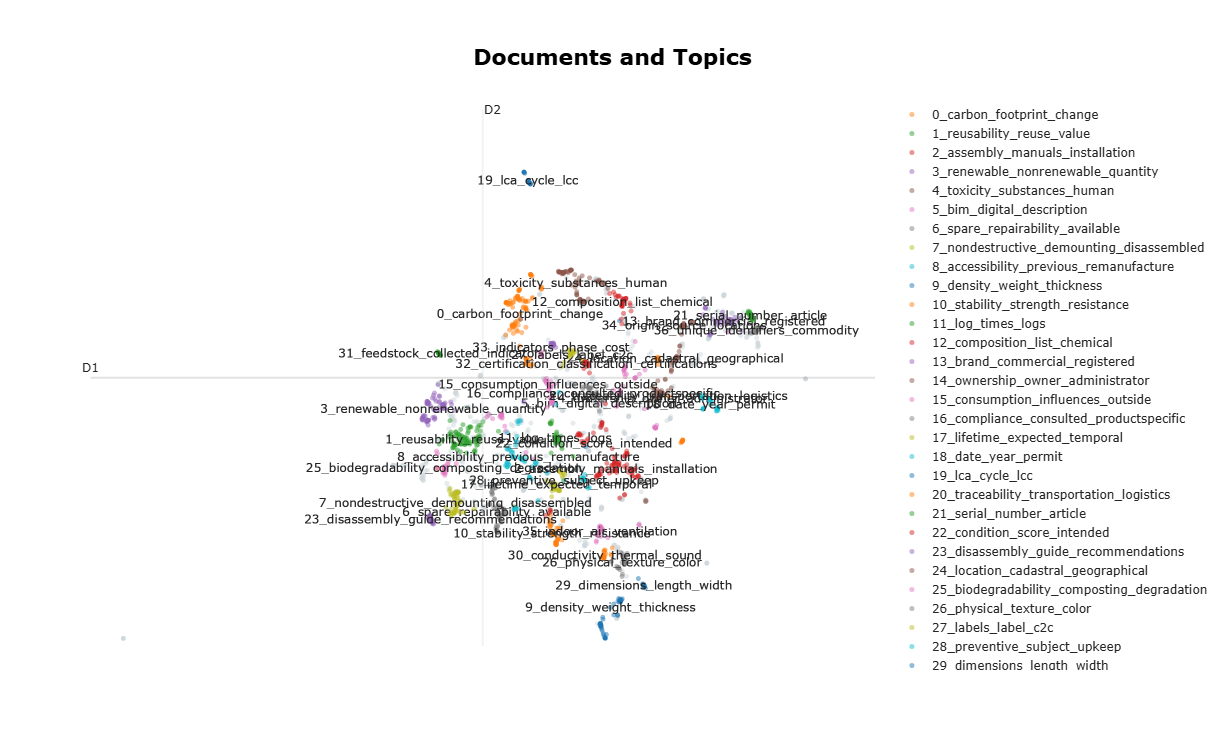

In [19]:
description_topic_model.visualize_documents(df["data_point"],  embeddings=description_embeddings)

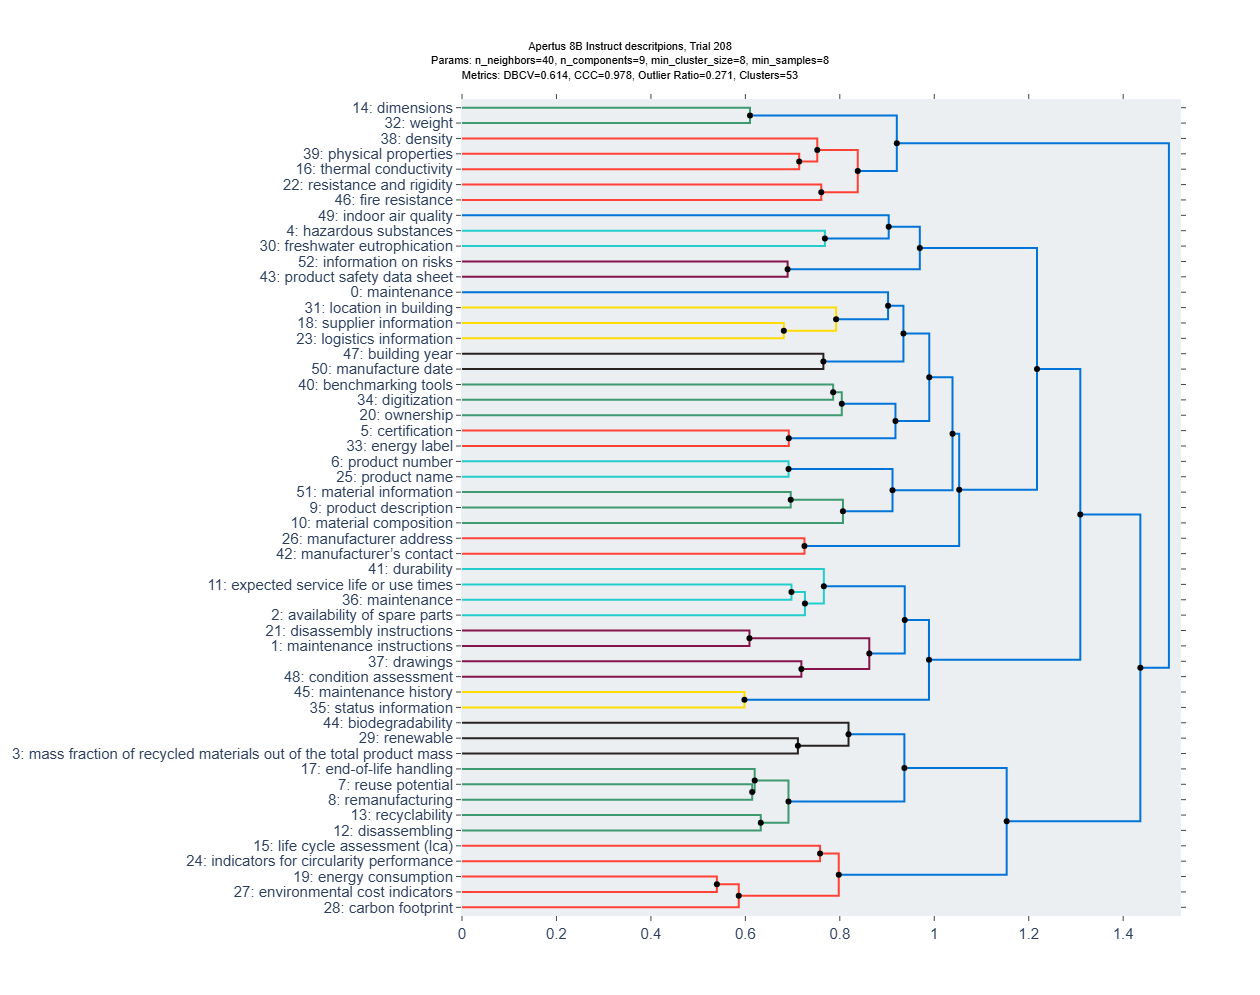

In [20]:
# Define a mapping from topic label -> custom hover text
custom_hover_map = {}
for v, k in zip(data_points_per_description_topic, label_per_description_topic):
    other_data_points = []
    for point in v['data_points']:
        if point['data_point'] in other_data_points:
            continue
        other_data_points.append(point['data_point'])
    
    custom_hover_map[k] = ";<br>".join(other_data_points[1:6])

fig_hierarchy.update_layout(
    hoverlabel=dict(
        align='left',   # moves text inside hover box to the right
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)

for trace in fig_hierarchy.data:
    if hasattr(trace, "text") and trace.text is not None:
        trace.hovertext = [
            f"<span style='display:inline-block; width:100px'></span>{custom_hover_map.get(t, t)}"
            for t in trace.text
        ]
        #trace.hovertemplate = "%{hovertext}<extra></extra>"  # clean hover box


# Save or show the updated plot
fig_hierarchy.show()


In [12]:
from pprint import pprint

def build_nested_dict(start, tree, hier_topics):
    """
    Convert a hierarchical tree into a nested dictionary.
    
    Parameters:
    - start: root node
    - tree: dict mapping parent -> list of children
    - hier_topics: DataFrame with hierarchical info (optional, used for distances)
    
    Returns:
    - nested dictionary representing the tree
    """
    
    def _build(parent):
        # If parent has no children, return empty dict
        if parent not in tree:
            return {}
        
        children = tree[parent]
        nested = {}
        
        for child in children:
            nested[child] = _build(child)
        
        return nested
    
    return {start: _build(start)}


tree = {
    str(linkage_matrix.shape[0] + row): [
        str(linkage_matrix[row, 0]),
        str(linkage_matrix[row, 1]),
    ]
    for row in range(linkage_matrix.shape[0])
}


pprint(build_nested_dict(str(linkage_matrix.shape[0] * 2 - 1), tree, hierarchical_topics))

{'91': {'87.0': {}, '91.0': {}}}


In [48]:
description_topic_model.get_topic_info().iloc[20].Representation         

['weight',
 'quantity',
 'pattern',
 'numerical',
 'gwp',
 'interoperable',
 'scalable',
 'suited',
 'attributes',
 'gravity']

In [42]:
from pprint import pprint
from scipy.cluster.hierarchy import linkage, to_tree


def build_tree_dict(node):
    if node.is_leaf():
        return {
            "0_topic_id": node.id,
            "1_topic_name": str(description_topic_model.get_topic_info().CustomName[description_topic_model.get_topic_info().Topic.astype(int) == node.id].iloc[0]),
            "2_data_points": list(set([p['data_point'] + " (" + p['original_source'] + ")" for p in data_points_per_description_topic[node.id + 1]['data_points']]))
        }
    return {
        "0_topic_id": node.id,
        "1_topic_name": str(hierarchical_topics.Parent_Name[hierarchical_topics.Parent_ID.astype(int) == node.id].iloc[0]),
        "2_children": [build_tree_dict(node.left),build_tree_dict(node.right)]
    }


root, nodes = to_tree(linkage_matrix, rd=True)

tree_dict = build_tree_dict(root)

with open(f"./results/Phi-4-mini/251113_grouped_datapoints_trial_{int(descriptions_trials_data.iloc[i]['number'])}_Phi-4-mini.json", "w") as f:
        json.dump(tree_dict, f, indent=4)
    
pprint(tree_dict)

{'0_topic_id': 118,
 '1_topic_name': 'instructions_ability_ensuring_provided_safety',
 '2_children': [{'0_topic_id': 115,
                 '1_topic_name': 'carbon_sustainability_footprint_reducing_consumption',
                 '2_children': [{'0_topic_id': 90,
                                 '1_topic_name': 'carbon_footprint_lca_water_al',
                                 '2_children': [{'0_topic_id': 14,
                                                 '1_topic_name': '14: life '
                                                                 'cycle '
                                                                 'assessment '
                                                                 '(lca)',
                                                 '2_data_points': ['acidification '
                                                                   'potential '
                                                                   '(ap) '
                                              

In [20]:
linkage_matrix

array([[ 25.        ,  18.        ,   0.57918583,   2.        ],
       [  5.        ,  55.        ,   0.58818242,   2.        ],
       [ 32.        ,  60.        ,   0.59722779,   3.        ],
       [ 24.        ,  12.        ,   0.60082476,   2.        ],
       [ 34.        ,  53.        ,   0.60299018,   2.        ],
       [ 20.        ,   8.        ,   0.60638466,   2.        ],
       [  6.        ,  19.        ,   0.62094178,   2.        ],
       [ 65.        ,   4.        ,   0.62529701,   3.        ],
       [ 10.        ,  47.        ,   0.62651376,   2.        ],
       [ 23.        ,  57.        ,   0.62978604,   2.        ],
       [  2.        ,   7.        ,   0.63175267,   2.        ],
       [ 31.        ,  16.        ,   0.6481574 ,   2.        ],
       [ 28.        ,  69.        ,   0.65052302,   3.        ],
       [ 30.        ,   9.        ,   0.6535169 ,   2.        ],
       [ 15.        ,  27.        ,   0.66733306,   2.        ],
       [ 13.        ,   1

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [30.0, 30.0, 45.0, 45.0],
  [10.0, 10.0, 37.5, 37.5],
  [75.0, 75.0, 85.0, 85.0],
  [80.0, 80.0, 95.0, 95.0],
  [65.0, 65.0, 87.5, 87.5],
  [55.0, 55.0, 76.25, 76.25],
  [105.0, 105.0, 115.0, 115.0],
  [125.0, 125.0, 135.0, 135.0],
  [110.0, 110.0, 130.0, 130.0],
  [145.0, 145.0, 155.0, 155.0],
  [120.0, 120.0, 150.0, 150.0],
  [65.625, 65.625, 135.0, 135.0],
  [165.0, 165.0, 175.0, 175.0],
  [185.0, 185.0, 195.0, 195.0],
  [190.0, 190.0, 205.0, 205.0],
  [170.0, 170.0, 197.5, 197.5],
  [215.0, 215.0, 225.0, 225.0],
  [183.75, 183.75, 220.0, 220.0],
  [100.3125, 100.3125, 201.875, 201.875],
  [245.0, 245.0, 255.0, 255.0],
  [235.0, 235.0, 250.0, 250.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [265.0, 265.0, 282.5, 282.5],
  [305.0, 305.0, 315.0, 315.0],
  [273.75, 273.75, 310.0, 310.0],
  [291.875, 291.875, 325.0, 325.0],
  [242.5, 242.5, 308.4375, 308.4375],
  [151.09375, 151.09375, 275.46875, 

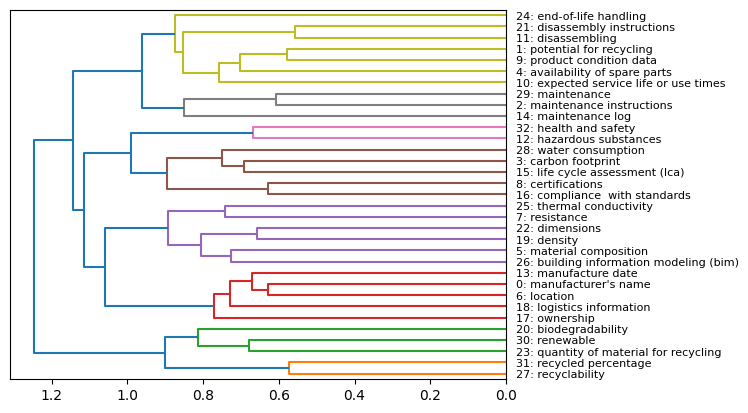

In [48]:
sch.dendrogram(
        linkage_matrix,
        orientation="left",
        labels=label_per_description_topic[description_topic_model._outliers:],
        no_plot=False,
        color_threshold=color_threshold,
    )